In [4]:
import numpy as np
import matplotlib.pyplot as plt 
import math
import sympy as sp
from matplotlib import cm

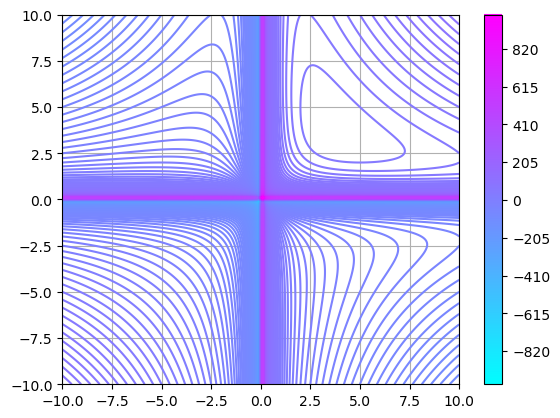

In [54]:
# upr 1


x = np.concatenate([np.linspace(-10, -.1, 1000), np.linspace(.1, 10, 1000)])
y = np.concatenate([np.linspace(-10, -.1, 1000), np.linspace(.1, 10, 1000)])
X, Y = np.meshgrid(x, y)
Z = X * Y + 50 / X + 50 / Y

fig, ax = plt.subplots()
cs = ax.contour(X, Y, Z, 400, cmap=cm.cool)
fig.colorbar(cs)
ax.grid()

In [59]:
from scipy.optimize import fmin

def f(t):
    x, y = t
    return x * y + 50 / x + 50 / y

minimum, f_min, _, _, _ = fmin(f, np.array([5, 5]), xtol=1e-9, disp=False, full_output=True)
print('Min:', minimum)
print('f:', f_min)

Min: [3.68403156 3.68403151]
f: 40.7162642489236


In [67]:
# upr 2

def dff(f, x, y, x0, y0):
    dfdx = sp.diff(f, x).subs({'x': x0, 'y': y0})
    dfdy = sp.diff(f, x).subs({'x': x0, 'y': y0})
    d2fdx2 = sp.diff(sp.diff(f, x), x).subs({'x': x0, 'y': y0})
    d2fdy2 = sp.diff(sp.diff(f, y), y).subs({'x': x0, 'y': y0})
    d2fdxdy = sp.diff(sp.diff(f, x), y).subs({'x': x0, 'y': y0})
    return dfdx, dfdy, d2fdx2, d2fdx2 * d2fdy2 - d2fdxdy**2


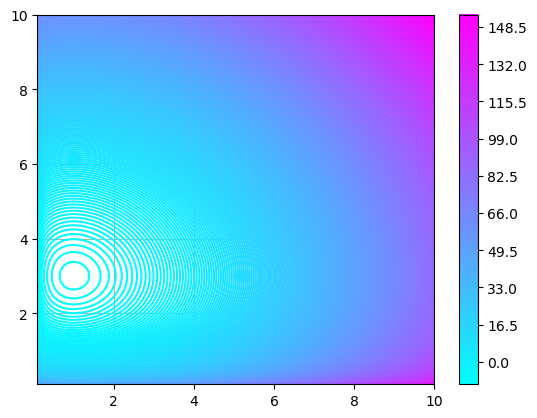

In [68]:
# upr 3

# a)

x = np.linspace(.1, 10, 1000)
y = np.linspace(.1, 10, 1000)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2 - 2 * np.log(X) - 18 * np.log(Y)

fig, ax = plt.subplots()
cs = ax.contour(X, Y, Z, 400, cmap=cm.cool)
fig.colorbar(cs)
ax.grid()

In [69]:
def f(t):
    x, y = t
    return x**2 + y**2 - 2 * np.log(x) - 18 * np.log(y)

minimum, f_min, _, _, _ = fmin(f, np.array([2, 2]), xtol=1e-9, disp=False, full_output=True)
print('Min:', minimum)
print('f:', f_min)

Min: [1. 3.]
f: -9.775021196025977


In [74]:
# 3 

# b)

x = sp.Symbol('x')
y = sp.Symbol('y')
e = x**2 + y**2 - 2 * sp.log(x) - 18 * sp.log(y)
dfdx0, dfdy0, m1, m2 = dff(e, x, y, 1, 3)
print('Необходимое условие:', dfdx0, dfdy0)
print('Достаточное условие:', m1, m2)
print('В точке (1, 3) минимум')

Необходимое условие: 0 0
Достаточное условие: 4 16
В точке (1, 3) минимум


In [123]:
# upr 4

def stat(f, x, y, z):
    dfdx = sp.diff(f, x)
    dfdy = sp.diff(f, y)
    dfdz = sp.diff(f, z)
    s = sp.solve([dfdx, dfdy, dfdz])
    for i in s:
        x0, y0, z0 = sp.N(i[x]), sp.N(i[y]), sp.N(i[z])
        print('точка возможного экстремума: ', x0, y0, z0)
        d2fdx2 = sp.diff(dfdx, x).subs({'x': x0, 'y': y0, 'z': z0})
        d2fdy2 = sp.diff(dfdy, y).subs({'x': x0, 'y': y0, 'z': z0})
        d2fdz2 = sp.diff(dfdz, z).subs({'x': x0, 'y': y0, 'z': z0})
        d2fdxdy = sp.diff(dfdx, y).subs({'x': x0, 'y': y0, 'z': z0})
        d2fdxdz = sp.diff(dfdx, z).subs({'x': x0, 'y': y0, 'z': z0})
        d2fdydz = sp.diff(dfdy, z).subs({'x': x0, 'y': y0, 'z': z0})
        m1 = d2fdx2
        m2 = d2fdx2 * d2fdy2 - d2fdxdy**2
        try:
            a = [[float(d2fdx2), float(d2fdxdy), float(d2fdxdz)], 
                 [float(d2fdxdy), float(d2fdy2), float(d2fdydz)], 
                 [float(d2fdxdz), float(d2fdydz), float(d2fdz2)]]
        except TypeError as e:
            print('\tчисло не является действительным')
            continue
        m3 = float(np.linalg.det(np.array(a)))
        print('\tглавные миноры матрицы:', m1, m2, m3, sep='\n\t\t')
        if (m1 > 0 and m2 > 0 and m3 > 0):
            print('\t точка минимума')
        elif (m1 < 0 and m2 > 0 and m3 < 0):
            print('\t точка максимума')
        elif (m3 != 0):
            print('\t в точке не достигается экстремума')
        else:
            print('\t признак не дает ответа о характере точки')

In [125]:
# upr 5

x = sp.Symbol('x')
y = sp.Symbol('y')
z = sp.Symbol('z')
u = x + y / x + z / y + 2 / z
stat(u, x, y, z)

точка возможного экстремума:  -1.18920711500272 1.41421356237310 -1.68179283050743
	главные миноры матрицы:
		-1.68179283050743
		1.50000000000000
		-0.8408964152537147
	 точка максимума
точка возможного экстремума:  1.18920711500272 1.41421356237310 1.68179283050743
	главные миноры матрицы:
		1.68179283050743
		1.50000000000000
		0.8408964152537147
	 точка минимума
точка возможного экстремума:  -1.18920711500272*I -1.41421356237310 1.68179283050743*I
	число не является действительным
точка возможного экстремума:  1.18920711500272*I -1.41421356237310 -1.68179283050743*I
	число не является действительным
